In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [2]:
digits = datasets.load_digits()

digits.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

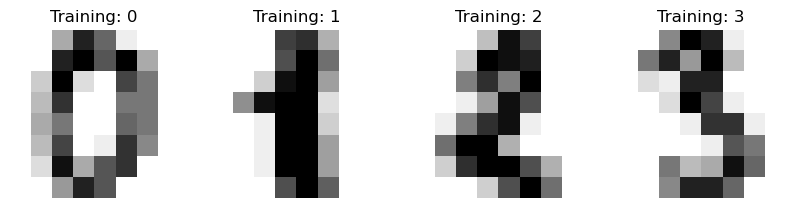

In [3]:
_, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3))
for ax, image, label in zip(axes, digits.images, digits.target):
    ax.set_axis_off()
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
    ax.set_title("Training: %i" % label)

In [4]:
X = digits.data/digits.data.max()
#X = digits.data
value = 5
y = np.array([1 if target==value else 0 for target in digits.target])

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, shuffle=False
)

In [6]:
LR = LogisticRegression(random_state=42)
LR.fit(X_train, y_train)

y_pred = LR.predict(X_test)

accuracy_score(y_test, y_pred)

0.9844271412680756

In [7]:
print(
    f"Classification report for classifier {LR}:\n\n"
    f"{classification_report(y_test, y_pred)}\n"
)

Classification report for classifier LogisticRegression(random_state=42):

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       808
           1       0.94      0.90      0.92        91

    accuracy                           0.98       899
   macro avg       0.97      0.95      0.96       899
weighted avg       0.98      0.98      0.98       899




In [8]:
from sklearn.multiclass import OneVsRestClassifier

X = digits.data/digits.data.max()
#X = digits.data
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, shuffle=False
)

clf = OneVsRestClassifier(LogisticRegression(random_state=42))
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(
    f"Classification report for classifier {clf}:\n"
    f"{classification_report(y_test, y_pred)}\n"
)

Classification report for classifier OneVsRestClassifier(estimator=LogisticRegression(random_state=42)):
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        88
           1       0.90      0.85      0.87        91
           2       1.00      0.98      0.99        86
           3       0.97      0.85      0.91        91
           4       0.98      0.93      0.96        92
           5       0.90      0.95      0.92        91
           6       0.96      0.99      0.97        91
           7       0.96      0.99      0.97        89
           8       0.93      0.88      0.90        88
           9       0.81      0.93      0.87        92

    accuracy                           0.93       899
   macro avg       0.94      0.93      0.93       899
weighted avg       0.93      0.93      0.93       899




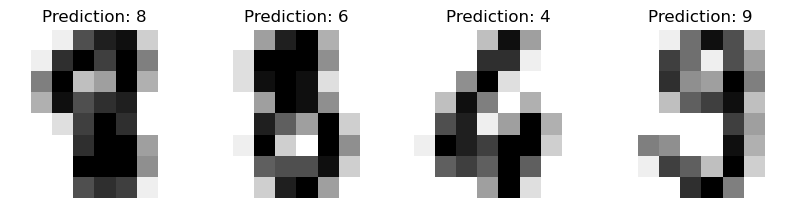

In [9]:
_, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3))
for ax, image, prediction in zip(axes, X_test, y_pred):
    ax.set_axis_off()
    image = image.reshape(8, 8)
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
    ax.set_title(f"Prediction: {prediction}")

In [10]:
# Required packages
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier

In [11]:
# Generate and extract features and target data
X, y = make_classification(n_samples=2000,
                           n_features=4,
                           n_informative=2, 
                           n_redundant=0,
                           random_state=42, 
                           shuffle=False)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.7, shuffle=False
)

In [12]:
# Create decision tree and train it
DTClassifier = DecisionTreeClassifier(criterion = 'gini',
                                      splitter = 'best',
                                      max_depth = None,
                                      min_samples_leaf = 100)
DTClassifier.fit(X_train, y_train)
DTClassifier.score(X_test, y_test)

0.8521428571428571

In [13]:
# Bagging
bagging = BaggingClassifier(DTClassifier,
                            n_estimators = 20,
                            max_samples = 1.0,
                            bootstrap = True,
                            bootstrap_features = False)
bagging.fit(X_train, y_train)
bagging.score(X_test, y_test)

0.8885714285714286

In [14]:
# Random Forest
RF = RandomForestClassifier(criterion = 'gini',
                            n_estimators=10, 
                            max_depth=None,
                            min_samples_leaf = 100, 
                            random_state=0)
RF.fit(X_train, y_train)
RF.score(X_test, y_test)

0.8607142857142858

In [15]:
# Adaboost
ABC = AdaBoostClassifier(n_estimators=100, random_state=0)
ABC.fit(X_train, y_train)
ABC.score(X_test, y_test)

0.7407142857142858

In [16]:
X = digits.data
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, shuffle=False
)

In [17]:
from sklearn import svm

# Create a classifier: a support vector classifier
clf = svm.SVC(kernel='rbf', gamma=0.001)

# Learn the digits on the train subset
clf.fit(X_train, y_train)

# Predict the value of the digit on the test subset
y_pred = clf.predict(X_test)

In [18]:
print(
    f"Classification report for classifier {clf}:\n"
    f"{classification_report(y_test, y_pred)}\n"
)

Classification report for classifier SVC(gamma=0.001):
              precision    recall  f1-score   support

           0       1.00      0.99      0.99        88
           1       0.99      0.97      0.98        91
           2       0.99      0.99      0.99        86
           3       0.98      0.87      0.92        91
           4       0.99      0.96      0.97        92
           5       0.95      0.97      0.96        91
           6       0.99      0.99      0.99        91
           7       0.96      0.99      0.97        89
           8       0.94      1.00      0.97        88
           9       0.93      0.98      0.95        92

    accuracy                           0.97       899
   macro avg       0.97      0.97      0.97       899
weighted avg       0.97      0.97      0.97       899




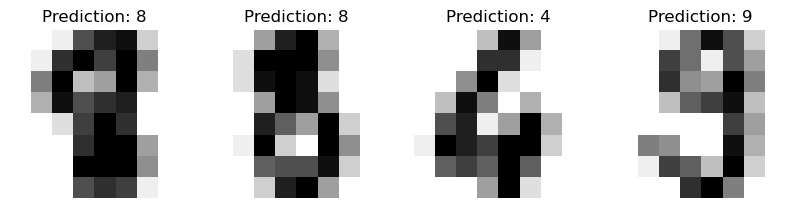

In [19]:
_, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3))
for ax, image, prediction in zip(axes, X_test, y_pred):
    ax.set_axis_off()
    image = image.reshape(8, 8)
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
    ax.set_title(f"Prediction: {prediction}")